[]
[0.0, 5.303315364902999e-05, 0.00014849474108136613, 0.00024415668681178413, 0.000340023953219705, 0.0004352867780002458, 0.0005321339967123609, 0.000628863404499012, 0.0007253011552946306, 0.0008210824247658456, 0.0009160141155529586, 0.0010100047638763265, 0.0011023876449836186, 0.0011930791088151475, 0.00128128645394161, 0.001366736356623035, 0.0014486457882448107, 0.0015264121444161255, 0.0015991393598810335, 0.001665911710837271, 0.0017258061291380222, 0.0017777291909752526, 0.0018204845412759327, 0.001852794669039393, 0.0018732620688235275, 0.0018803959123118523, 0.0018725767071066388, 0.0018480725868164534, 0.0018050191555241176, 0.0017414674929260331, 0.0016552966480314324, 0.0015453045044142918, 0.0014086751409763385, 0.001256977722667506, 0.001079010669903018, 0.0008664722963764346, 0.0008485152266924584, 0.0008275830532242867, 0.0007875883297586374, 0.0008555276031890619, 0.0009046316883861763, 0.0008931131331488873, 0.0008858934399788854, 0.0008048600929463606, 0.0006501

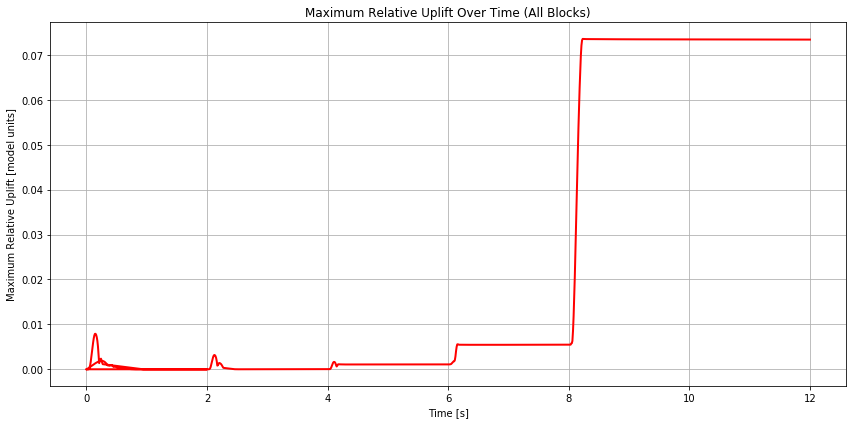

First few times: [0.0, 0.010003347881138325, 0.020013565197587013, 0.03000602498650551, 0.04000945761799812, 0.05000763013958931, 0.060001686215400696, 0.07000037282705307, 0.08001159876585007, 0.09001229703426361]
First few max uplift values: [0.0, 5.303315364902999e-05, 0.00014849474108136613, 0.00024415668681178413, 0.000340023953219705, 0.0004352867780002458, 0.0005321339967123609, 0.000628863404499012, 0.0007253011552946306, 0.0008210824247658456]


In [6]:
import csv
import matplotlib.pyplot as plt

# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# === CONFIGURATION ===
csv_file = 'relative_uplift_timeseries_06.csv'

# === LOAD DATA ===
times = []
block_names = []
uplift_data = {}

with open(csv_file, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)

    # Header now has: ['Step', 'Time', 'B-1-1', ...]
    block_names = header[2:]   # skip Step and Time columns

    for block in block_names:
        uplift_data[block] = []

    for row in reader:
        time_str = row[1]
        if time_str:
            times.append(float(time_str))
        else:
            times.append(None)

        for i, block in enumerate(block_names):
            val = row[i + 2]
            uplift_data[block].append(float(val) if val else None)

# === COMPUTE MAX UPLIFT AT EACH TIME STEP ===
max_uplift = []
print(max_uplift)

for i in range(len(times)):
    # Gather all uplift values at time index i
    values_at_t = [
        uplift_data[block][i]
        for block in block_names
        if uplift_data[block][i] is not None
    ]

    if values_at_t:
        max_uplift.append(max(values_at_t))
    else:
        max_uplift.append(None)
print(max_uplift)
# === PLOT MAX UPLIFT ===
plt.figure(figsize=(12, 6))
plt.plot(times, max_uplift, color='red', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Maximum Relative Uplift [model units]')
plt.title('Maximum Relative Uplift Over Time (All Blocks)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("First few times:", times[:10])
print("First few max uplift values:", max_uplift[:10])



Grid width: 4.900 m


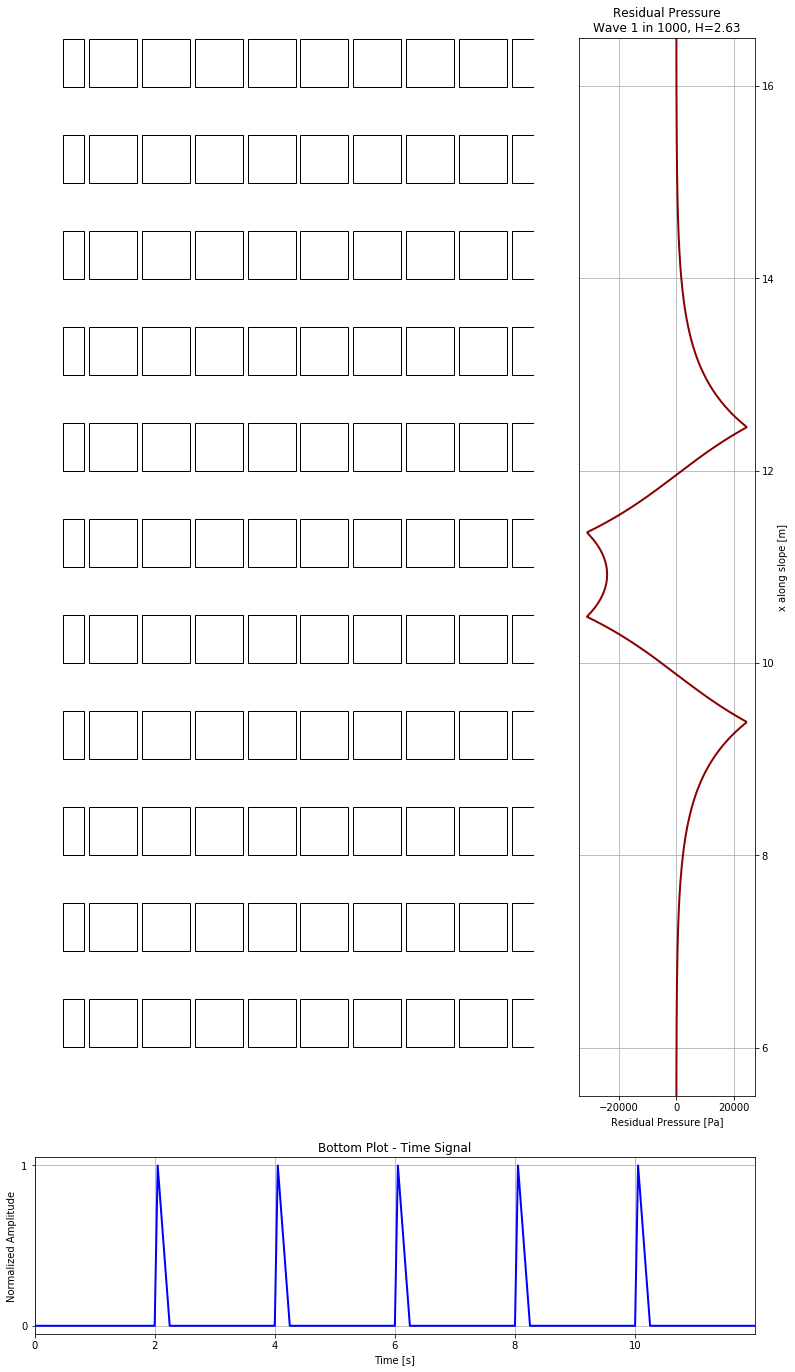

✅ Saved: block_grid_with_residual_pressure.png


In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.linalg import solve

# ------------------------------
# Wave simulation setup
# ------------------------------

Hs = 1.0

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)
H_wave_width = Hs

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Brick layout parameters ---
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05

# Compute grid width for even rows (widest rows)
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")


# --- Generate wave heights (Rayleigh) ---
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Initialize storage ---
block_pressures_per_wave = {}
residual_profiles = {}
wave_pressures = {}
filter_responses = {}

# Loop through each wave
for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[wave_name] = block_avg_pressures

# ------------------------------
# Create time signal for bottom plot
# ------------------------------

# --- Pulse signal ---
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Figure with gridspec
# ------------------------------

# Pick which wave to plot in right-side plot
# example:
wave_to_plot = list(residual_profiles.keys())[0]   # pick Wave 3, for example

fig = plt.figure(figsize=(10, 18))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.1
)

# === TOP LEFT AXES (block grid) ===
ax_grid = fig.add_subplot(gs[0, 0])

rows = 22
current_y = 0

for row in range(rows):
    if row % 2 == 0:
        for i in range(10):
            x_rect = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle(
                (x_pos, current_y),
                block_w, full_h,
                edgecolor='black',
                facecolor=color,
                linewidth=2.0           # ← make thicker
            )
            ax_grid.add_patch(rect)
    else:
        x_rect = 0
        rect = patches.Rectangle(
            (x_rect, current_y), half_w, half_h,
            edgecolor='black', facecolor='white'
        )
        ax_grid.add_patch(rect)
        x_rect += half_w + horizontal_spacing
        for i in range(9):
            rect = patches.Rectangle(
                (x_rect, current_y), full_w, full_h,
                edgecolor='black', facecolor='white'
            )
            ax_grid.add_patch(rect)
            x_rect += full_w + horizontal_spacing
        rect = patches.Rectangle(
            (x_rect, current_y), half_w, half_h,
            edgecolor='black', facecolor='white'
        )
        ax_grid.add_patch(rect)

    current_y += full_h

# Add margin
margin_x = 0.01
margin_y = 0.01

ax_grid.set_aspect('equal')
ax_grid.set_xlim(-margin_x, grid_width + margin_x)
ax_grid.set_ylim(-margin_y, current_y + margin_y)
ax_grid.axis('off')

# === TOP RIGHT AXES (side plot) ===
ax_side = fig.add_subplot(gs[0, 1])

# Plot residual vs. x
ax_side.plot(residual_profiles[wave_to_plot], x,
             color='darkred', linewidth=2)
ax_side.invert_yaxis()
ax_side.set_xlabel('Residual Pressure [Pa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)  # Adjust limits for clarity
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title(f"Residual Pressure\n{wave_to_plot}")
ax_side.grid(True)

# === BOTTOM AXES (bottom plot spanning both columns) ===
ax_bottom = fig.add_subplot(gs[1, :])

ax_bottom.plot(df_signal["Time"], df_signal["Signal"],
               color='blue', linewidth=2)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

plt.savefig(
    "block_grid_with_residual_pressure.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()

print(f"✅ Saved: block_grid_with_residual_pressure.png")


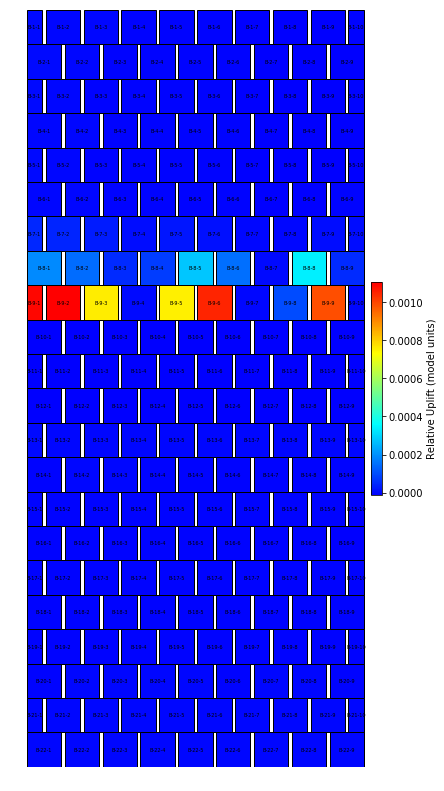

In [19]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
csv_path = 'relative_uplift_timeseries_06.csv'
target_time = 6.03    # time in seconds you want to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)

# Detect time column automatically
if df.columns[0].lower() == "step":
    time_col = df.columns[1]
else:
    time_col = df.columns[0]

# Round time to 2 decimals for matching
df[time_col] = df[time_col].round(2)
row_df = df[df[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# Drop time/step columns to get only block data
block_data = row_df.drop(columns=[df.columns[0], df.columns[1]]).iloc[0]
block_names_all = block_data.index.tolist()

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_data.values),
                         vmax=np.nanmax(block_data.values))

# --- Define custom colormap ---
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)

# Color for blocks with no data
no_data_color = "lightgray"

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))

# Loop through rows (1 = top, 22 = bottom)
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    
    is_half = (row_num % 2 == 1)
    
    if is_half:
        # Odd rows: half + 8 full + half → 10 bricks
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        # Even rows: 9 full bricks
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]
    
    x = 0.0
    
    for block_w, block_name in block_sequence:
        # Get block value
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color
        
        # Draw rectangle
        rect = patches.Rectangle(
            (x, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color
        )
        ax.add_patch(rect)
        
        # Draw block name in center
        ax.text(
            x + block_w/2,
            current_y + full_h/2,
            block_name,
            ha='center',
            va='center',
            fontsize=5,
            color='black'
        )
        
        x += block_w + h_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x)
ax.set_ylim(0, rows * full_h)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Relative Uplift (model units)')

# --- Show figure ---
plt.tight_layout()
plt.show()


✅ Found blocks in first row: ['B-1-1', 'B-1-10', 'B-1-2', 'B-1-3', 'B-1-4', 'B-1-5', 'B-1-6', 'B-1-7', 'B-1-8', 'B-1-9']


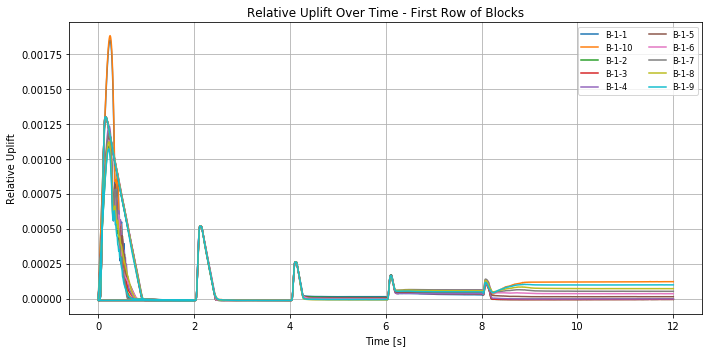

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_path = 'relative_uplift_timeseries_06.csv'

# --- Load CSV ---
df = pd.read_csv(csv_path)

# Detect time column automatically
if df.columns[0].lower() == "step":
    time_col = df.columns[1]
else:
    time_col = df.columns[0]

# Extract time array
time_values = df[time_col]

# Find block columns for first row (B-1-…)
block_cols = [col for col in df.columns if col.startswith('B-1-')]

print(f"✅ Found blocks in first row: {block_cols}")

# Plot
plt.figure(figsize=(10,5))

for col in block_cols:
    plt.plot(time_values, df[col], label=col, linewidth=1.5)

plt.xlabel("Time [s]")
plt.ylabel("Relative Uplift")
plt.title("Relative Uplift Over Time - First Row of Blocks")
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 11.00 s belongs to Wave 5 in 1000, H=2.30


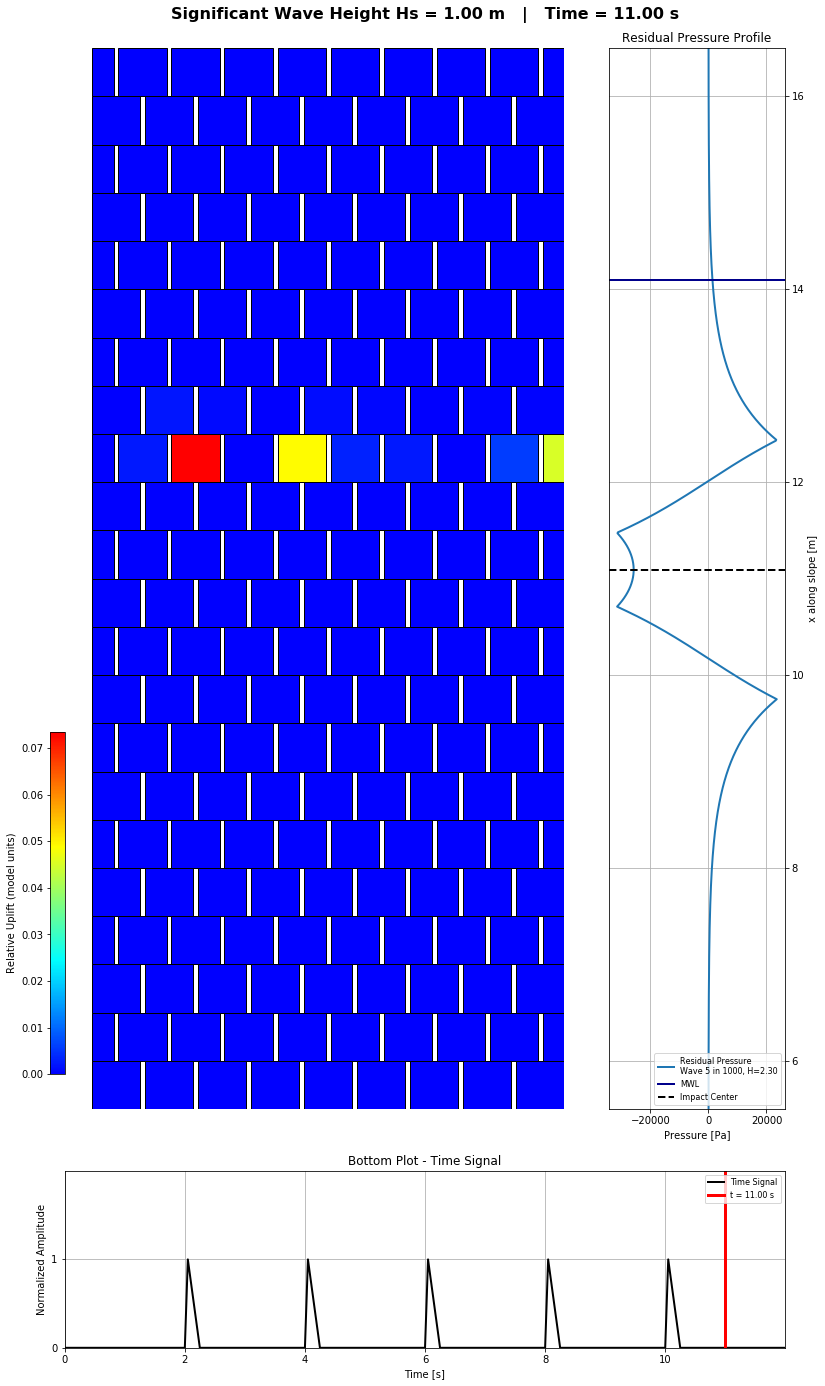

✅ Finished plotting block grid with uplift and residual pressure.


In [84]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable

target_time = 11    # time in seconds to visualize

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

# Compute grid width for even rows (widest rows)
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------

csv_path = 'relative_uplift_timeseries_06.csv'


df_uplift = pd.read_csv(csv_path)

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# Drop time columns to get only block data
block_data = row_df.drop(columns=[df_uplift.columns[0], df_uplift.columns[1]]).iloc[0]
block_names_all = block_data.index.tolist()

# Normalize colormap
norm = plt.Normalize(vmin=np.nanmin(block_data.values),
                     vmax=np.nanmax(block_data.values))

# Custom colormap: blue → red
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
# colors = ["#0000FF", "#FFCC00", "#FF0000"]
# colors = ["#0000FF", "#00BBFF", "#FFFFFF"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)

# Color for blocks with no data
no_data_color = "lightgray"

# ------------------------------
# Create time signal for bottom plot
# ------------------------------

# Pulse signal
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

# Wave simulation setup
Hs = 1.0
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# MWL x-position along slope
x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Pick a default wave in case no wave is active
wave_to_plot = list(residual_profiles.keys())[0]

# ------------------------------
# Determine active wave
# ------------------------------

active_wave = None

for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval

    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Create figure with subplots
# ------------------------------

fig = plt.figure(figsize=(10, 19))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.1
)

# === TOP LEFT AXES (block grid with uplift data) ===
ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    
    is_half = (row_num % 2 == 1)
    
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]
    
    x_pos = 0.0
    
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color
        
        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Add colorbar on the left side
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.2, 0.02, 0.25])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift (model units)')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# === TOP RIGHT AXES (residual profile of active wave only) ===
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

ax_side.plot(
    residual_vals,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)

# Plot MWL
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)

# Plot Impact Center
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)

ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [Pa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# === BOTTOM AXES (time signal) ===
ax_bottom = fig.add_subplot(gs[1, :])

ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)

# Add vertical line at target_time
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)

ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# Add figure title
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)

plt.show()

print("✅ Finished plotting block grid with uplift and residual pressure.")


In [88]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# ------------------------------
# CONFIGURATION
# ------------------------------

csv_path = 'relative_uplift_timeseries_06.csv'
target_time = 11.0   # time in seconds
D = 0.15             # block diameter in meters

# ------------------------------
# LOAD CSV
# ------------------------------

# Load the CSV
df_uplift = pd.read_csv(csv_path)

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round time for matching
df_uplift[time_col] = df_uplift[time_col].round(2)

# Find the row at the desired time
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# Drop time columns to keep only block data
block_data = row_df.drop(columns=[df_uplift.columns[0], df_uplift.columns[1]]).iloc[0]

# ------------------------------
# CALCULATE z_e / D
# ------------------------------

# Convert to array
uplift_values = block_data.values

# Compute normalized uplift
ze_over_D = uplift_values / D

# ------------------------------
# COUNT DAMAGE CATEGORIES
# ------------------------------

damage_counts = {
    1: 0,
    2: 0,
    3: 0,
    4: 0
}

# Classify each block
for val in ze_over_D:
    if np.isnan(val) or val <= 0:
        continue
    elif 0.05 < val < 0.33:
        damage_counts[1] += 1
    elif 0.33 < val < 0.67:
        damage_counts[2] += 1
    elif 0.67 < val < 1:
        damage_counts[3] += 1
    elif val > 1:
        damage_counts[4] += 1

# ------------------------------
# DISPLAY RESULTS
# ------------------------------

print(f"\n✅ Damage category summary at t = {target_time:.2f} s:\n")
for cat in [1, 2, 3, 4]:
    print(f"Damage category {cat}: {damage_counts[cat]} blocks")

# Create a Pandas DataFrame for tabular output
df_damage = pd.DataFrame({
    'Damage Category': [1, 2, 3, 4],
    'Number of Blocks': [damage_counts[i] for i in [1,2,3,4]]
})

print("\nDamage category table:\n")
print(df_damage)

# Optionally save to CSV
# df_damage.to_csv("damage_categories_summary.csv", index=False)



✅ Damage category summary at t = 11.00 s:

Damage category 1: 2 blocks
Damage category 2: 1 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

Damage category table:

   Damage Category  Number of Blocks
0                1                 2
1                2                 1
2                3                 0
3                4                 0
